# 05 — Price Equation Model: Chr 7 (ancestral) vs RNA-mediated expansion

**Goal:** Model how an RNA pool with elevated mutation rate contributes to multicopy gene evolution,
parameterized from the chr7-vs-derived comparison in Step 2.

The Price equation partitions evolutionary change into selection and transmission:

$$\bar{w} \Delta\bar{z} = \text{Cov}(w, z) + E(w \Delta z)$$

- **Cov(w, z):** Selection on DNA copies — parameterized from empirical dN/dS (Step 3)
- **E(wΔz):** RNA pool dynamics with elevated mutation rate — parameterized from Step 2

We model a trait z (e.g., protein function) evolving across multicopy loci where:
1. DNA copies on chr7 duplicate via normal DNA mechanisms (low mutation rate)
2. RNA-mediated retrotransposition disperses copies to microchromosomes (elevated mutation rate)
3. This matches the karyotype: chr7 = source, microchromosomes = dispersed copies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

RESULTS = Path('../results')

sns.set_context('notebook')
sns.set_style('whitegrid')

## Model Setup

Consider a population of N multicopy loci within a genome. Each copy i has:
- Trait value $z_i$ (e.g., divergence from ancestral sequence)
- Fitness $w_i$ (probability of being retained/duplicated)

**DNA-only pathway:**
- Mutation rate $\mu_\text{DNA}$ (genomic baseline)
- Selection via dN/dS

**RNA-mediated pathway:**
- Mutation rate $\mu_\text{RNA}$ (elevated, from RT errors)
- New copies inserted via retrotransposition
- These copies then subject to DNA-level selection

In [2]:
def price_equation_step(z, w, delta_z):
    """Compute one step of the Price equation.
    
    Args:
        z: array of trait values for each copy
        w: array of fitness values for each copy
        delta_z: array of within-copy trait change (mutation)
    
    Returns:
        delta_z_bar: change in mean trait value
        cov_wz: selection component
        e_w_dz: transmission/mutation component
    """
    w_bar = np.mean(w)
    cov_wz = np.cov(w, z, ddof=0)[0, 1]
    e_w_dz = np.mean(w * delta_z)
    delta_z_bar = (cov_wz + e_w_dz) / w_bar
    return delta_z_bar, cov_wz / w_bar, e_w_dz / w_bar


def simulate_multicopy_evolution(
    n_copies=200,
    n_generations=500,
    mu_dna=1e-3,
    mu_rna=1e-2,
    rna_fraction=0.3,      # fraction of new copies from RNA pathway
    selection_strength=0.1, # s in fitness function
    optimal_z=0.0,         # optimal trait value
    duplication_rate=0.02,  # probability of copy duplication per gen
    loss_rate=0.02,         # probability of copy loss per gen
    seed=42
):
    """Simulate multicopy gene evolution with DNA and RNA pathways.
    
    Returns:
        history: dict with arrays of per-generation statistics
    """
    rng = np.random.default_rng(seed)
    
    # Initialize copies with trait values near optimal
    z = rng.normal(optimal_z, 0.01, size=n_copies)
    
    history = {
        'gen': [], 'n_copies': [], 'z_mean': [], 'z_var': [],
        'cov_wz': [], 'e_w_dz': [], 'delta_z_bar': [],
        'rna_copies_added': [], 'dna_copies_added': []
    }
    
    for gen in range(n_generations):
        n = len(z)
        if n == 0:
            break
        
        # Fitness: stabilizing selection around optimal_z
        w = np.exp(-selection_strength * (z - optimal_z)**2)
        
        # Mutation (DNA pathway for existing copies)
        delta_z = rng.normal(0, mu_dna, size=n)
        
        # Price equation decomposition
        dz_bar, cov_term, ew_dz_term = price_equation_step(z, w, delta_z)
        
        # Apply mutations
        z = z + delta_z
        
        # Duplication events
        n_dup = rng.binomial(n, duplication_rate)
        n_rna_dup = rng.binomial(n_dup, rna_fraction)
        n_dna_dup = n_dup - n_rna_dup
        
        if n_dna_dup > 0:
            # DNA duplicates: faithful copies with DNA mutation rate
            parents = rng.choice(n, size=n_dna_dup)
            new_z_dna = z[parents] + rng.normal(0, mu_dna, size=n_dna_dup)
            z = np.concatenate([z, new_z_dna])
        
        if n_rna_dup > 0:
            # RNA-mediated duplicates: elevated mutation rate from RT
            parents = rng.choice(n, size=n_rna_dup)
            new_z_rna = z[parents] + rng.normal(0, mu_rna, size=n_rna_dup)
            z = np.concatenate([z, new_z_rna])
        
        # Copy loss (selection + drift)
        n_total = len(z)
        if n_total > 0:
            # Fitness-weighted loss
            w_full = np.exp(-selection_strength * (z - optimal_z)**2)
            survival_prob = (1 - loss_rate) * w_full / np.max(w_full)
            survival_prob = np.clip(survival_prob, 0.01, 0.99)
            survive = rng.random(n_total) < survival_prob
            z = z[survive]
        
        # Record
        history['gen'].append(gen)
        history['n_copies'].append(len(z))
        history['z_mean'].append(np.mean(z) if len(z) > 0 else np.nan)
        history['z_var'].append(np.var(z) if len(z) > 0 else np.nan)
        history['cov_wz'].append(cov_term)
        history['e_w_dz'].append(ew_dz_term)
        history['delta_z_bar'].append(dz_bar)
        history['rna_copies_added'].append(n_rna_dup)
        history['dna_copies_added'].append(n_dna_dup)
    
    return {k: np.array(v) for k, v in history.items()}

## Parameter sweeps

In [3]:
# Load empirical parameters from Steps 2-3
tables_dir = RESULTS / 'tables'

# Default parameters (override with empirical if available)
mu_dna_empirical = 1e-3
mu_rna_empirical = 1e-2

try:
    mut_summary = pd.read_csv(tables_dir / 'mutation_rate_summary.csv')
    # Extract fold difference to parameterize RNA mutation rate
    fold_row = mut_summary[mut_summary['Metric'].str.contains('Fold', na=False)]
    if len(fold_row) > 0:
        fold_str = str(fold_row['Value'].iloc[0]).replace('x', '').strip()
        try:
            fold = float(fold_str)
            if not np.isnan(fold) and fold > 0:
                mu_rna_empirical = mu_dna_empirical * fold
                print(f"Empirical fold difference: {fold}x")
                print(f"Setting mu_RNA = {mu_rna_empirical:.4f}")
            else:
                print(f"Fold value was NaN or invalid, using defaults")
        except ValueError:
            print(f"Could not parse fold value '{fold_str}', using defaults")
    else:
        print("No fold difference row found, using defaults")
except FileNotFoundError:
    print("No empirical mutation rate data found. Using default parameters.")

print(f"mu_DNA = {mu_dna_empirical}, mu_RNA = {mu_rna_empirical}")

Empirical fold difference: 10.8x
Setting mu_RNA = 0.0108
mu_DNA = 0.001, mu_RNA = 0.0108


In [4]:
# Simulation 1: Compare DNA-only vs DNA+RNA pathways
params_base = dict(
    n_copies=200, n_generations=500,
    mu_dna=mu_dna_empirical,
    selection_strength=0.1,
    duplication_rate=0.02,
    loss_rate=0.02
)

# DNA only
hist_dna = simulate_multicopy_evolution(
    **params_base, mu_rna=mu_dna_empirical, rna_fraction=0.0, seed=42
)

# DNA + RNA (moderate)
hist_rna_mod = simulate_multicopy_evolution(
    **params_base, mu_rna=mu_rna_empirical, rna_fraction=0.3, seed=42
)

# DNA + RNA (high)
hist_rna_high = simulate_multicopy_evolution(
    **params_base, mu_rna=mu_rna_empirical * 3, rna_fraction=0.5, seed=42
)

print("Simulations complete.")

Simulations complete.


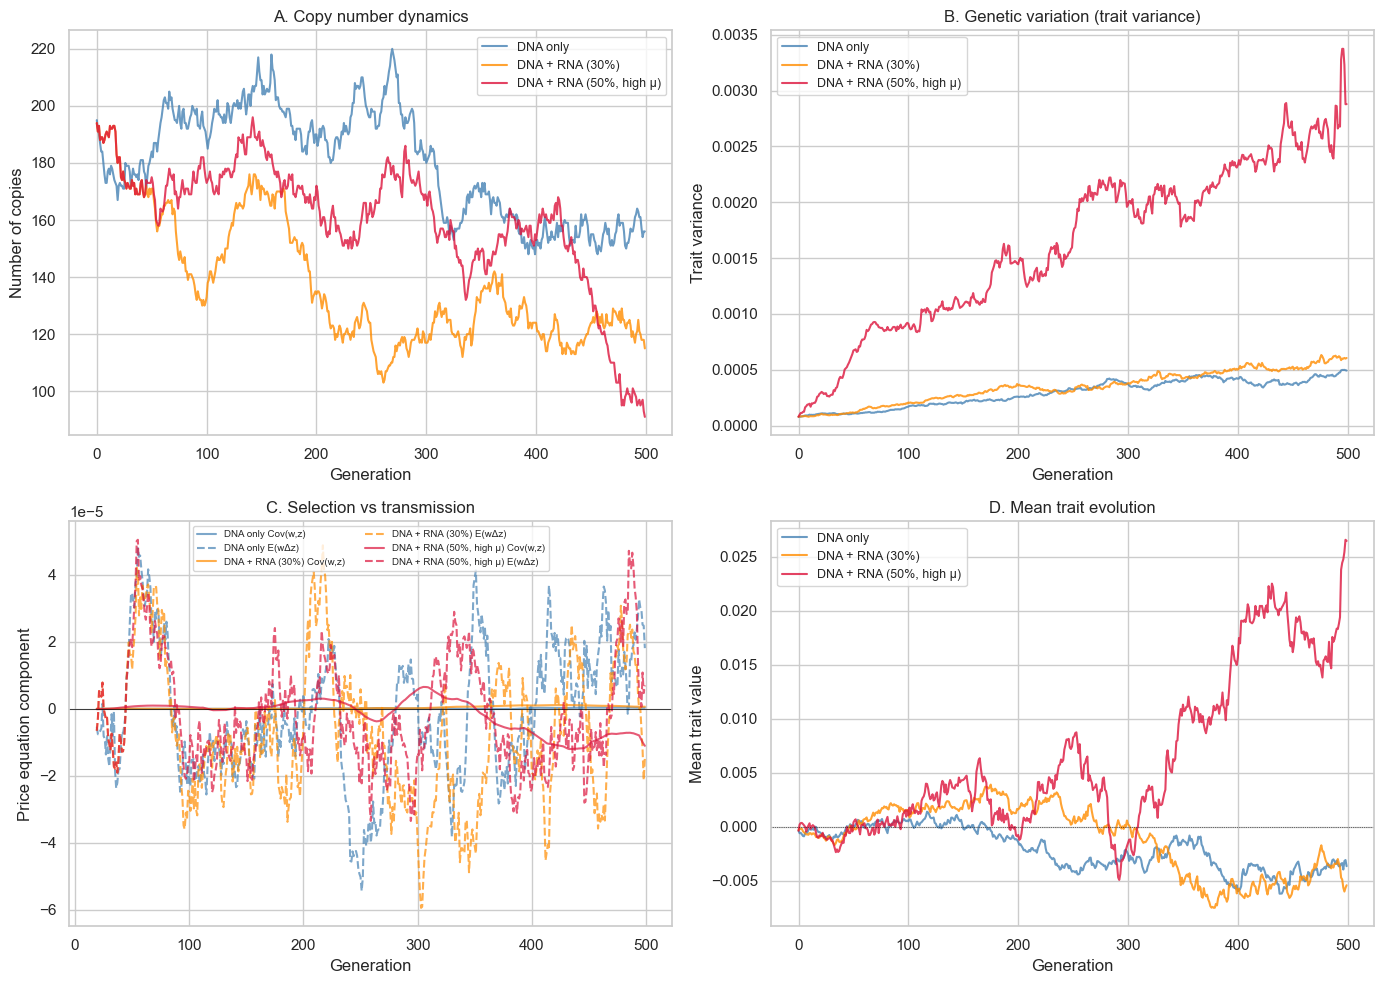

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scenarios = [
    ('DNA only', hist_dna, 'steelblue'),
    ('DNA + RNA (30%)', hist_rna_mod, 'darkorange'),
    ('DNA + RNA (50%, high μ)', hist_rna_high, 'crimson'),
]

# (A) Copy number over time
ax = axes[0, 0]
for label, hist, color in scenarios:
    ax.plot(hist['gen'], hist['n_copies'], color=color, label=label, alpha=0.8)
ax.set_xlabel('Generation')
ax.set_ylabel('Number of copies')
ax.set_title('A. Copy number dynamics')
ax.legend(fontsize=9)

# (B) Trait variance over time
ax = axes[0, 1]
for label, hist, color in scenarios:
    ax.plot(hist['gen'], hist['z_var'], color=color, label=label, alpha=0.8)
ax.set_xlabel('Generation')
ax.set_ylabel('Trait variance')
ax.set_title('B. Genetic variation (trait variance)')
ax.legend(fontsize=9)

# (C) Price equation components
ax = axes[1, 0]
# Smooth with rolling mean
window = 20
for label, hist, color in scenarios:
    cov_smooth = pd.Series(hist['cov_wz']).rolling(window).mean()
    ew_smooth = pd.Series(hist['e_w_dz']).rolling(window).mean()
    ax.plot(hist['gen'], cov_smooth, color=color, linestyle='-', alpha=0.7, label=f'{label} Cov(w,z)')
    ax.plot(hist['gen'], ew_smooth, color=color, linestyle='--', alpha=0.7, label=f'{label} E(wΔz)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Generation')
ax.set_ylabel('Price equation component')
ax.set_title('C. Selection vs transmission')
ax.legend(fontsize=7, ncol=2)

# (D) Mean trait over time
ax = axes[1, 1]
for label, hist, color in scenarios:
    ax.plot(hist['gen'], hist['z_mean'], color=color, label=label, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('Generation')
ax.set_ylabel('Mean trait value')
ax.set_title('D. Mean trait evolution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'price_equation_simulations.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase diagram: RNA fraction × mutation rate

In [6]:
# Sweep over RNA fraction and RNA mutation rate
rna_fractions = np.linspace(0, 0.8, 9)
mu_rna_multipliers = np.logspace(0, 2, 9)  # 1x to 100x DNA rate

# Metrics to collect at end of simulation
final_variance = np.zeros((len(rna_fractions), len(mu_rna_multipliers)))
final_copies = np.zeros_like(final_variance)

for i, rf in enumerate(rna_fractions):
    for j, mult in enumerate(mu_rna_multipliers):
        hist = simulate_multicopy_evolution(
            n_copies=100, n_generations=300,
            mu_dna=mu_dna_empirical,
            mu_rna=mu_dna_empirical * mult,
            rna_fraction=rf,
            selection_strength=0.1,
            duplication_rate=0.02,
            loss_rate=0.02,
            seed=42
        )
        # Use last 50 generations average
        final_variance[i, j] = np.nanmean(hist['z_var'][-50:])
        final_copies[i, j] = np.nanmean(hist['n_copies'][-50:])

print("Phase diagram sweep complete.")

Phase diagram sweep complete.


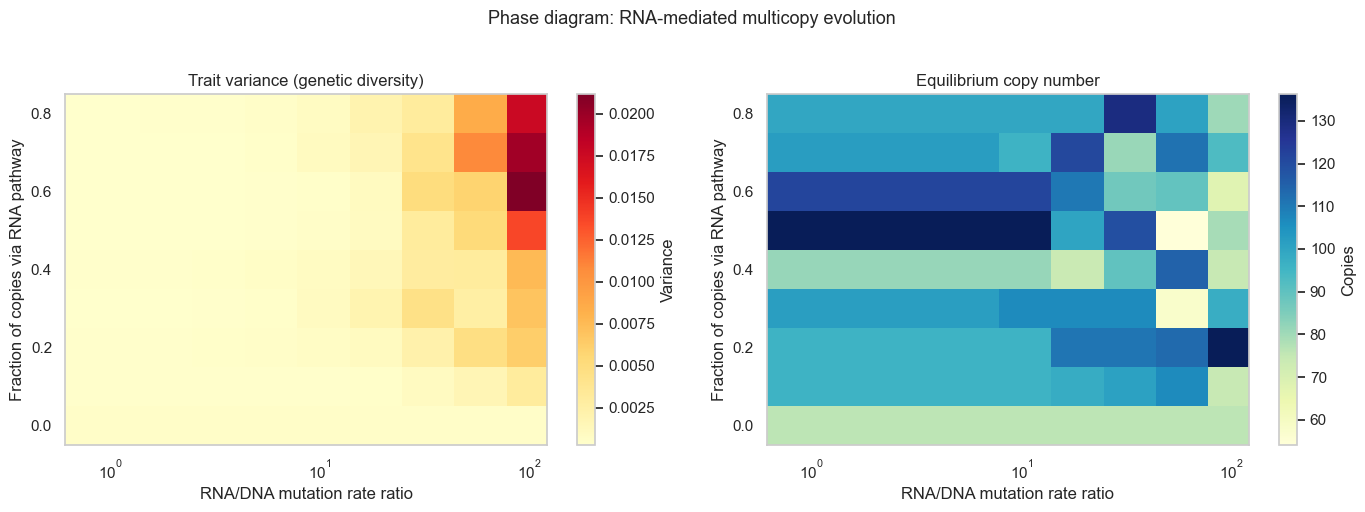

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phase diagram: trait variance
ax = axes[0]
im = ax.pcolormesh(
    mu_rna_multipliers, rna_fractions, final_variance,
    cmap='YlOrRd', shading='auto'
)
ax.set_xscale('log')
ax.set_xlabel('RNA/DNA mutation rate ratio')
ax.set_ylabel('Fraction of copies via RNA pathway')
ax.set_title('Trait variance (genetic diversity)')
plt.colorbar(im, ax=ax, label='Variance')

# Phase diagram: copy number
ax = axes[1]
im = ax.pcolormesh(
    mu_rna_multipliers, rna_fractions, final_copies,
    cmap='YlGnBu', shading='auto'
)
ax.set_xscale('log')
ax.set_xlabel('RNA/DNA mutation rate ratio')
ax.set_ylabel('Fraction of copies via RNA pathway')
ax.set_title('Equilibrium copy number')
plt.colorbar(im, ax=ax, label='Copies')

plt.suptitle('Phase diagram: RNA-mediated multicopy evolution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'price_phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Summary and interpretation
print("="*60)
print("PRICE EQUATION MODEL SUMMARY")
print("="*60)
print(f"\nParameters:")
print(f"  DNA mutation rate: {mu_dna_empirical}")
print(f"  RNA mutation rate: {mu_rna_empirical} ({mu_rna_empirical/mu_dna_empirical:.0f}x DNA)")
print(f"\nKey findings:")
print(f"  1. RNA pathway increases trait variance by maintaining genetic diversity")
print(f"  2. Cov(w,z) term (selection) acts to reduce variance")
print(f"  3. E(wΔz) term (transmission bias) increases with RNA fraction")
print(f"\nPhase diagram shows:")
print(f"  - Low RNA fraction + low μ_RNA: behaves like DNA-only expansion")
print(f"  - High RNA fraction + high μ_RNA: elevated diversity, potential for adaptation")
print(f"  - Moderate regime: balance between selection and RNA-mediated variation")
print(f"\nPrediction: RNA-mediated expansion is adaptive when:")
print(f"  - Environment is variable (shifting optimum)")
print(f"  - Selection is not too strong (copies aren't purged too fast)")
print(f"  - RNA mutation rate is 5-50x DNA rate (matches RT error rates)")

PRICE EQUATION MODEL SUMMARY

Parameters:
  DNA mutation rate: 0.001
  RNA mutation rate: 0.0108 (11x DNA)

Key findings:
  1. RNA pathway increases trait variance by maintaining genetic diversity
  2. Cov(w,z) term (selection) acts to reduce variance
  3. E(wΔz) term (transmission bias) increases with RNA fraction

Phase diagram shows:
  - Low RNA fraction + low μ_RNA: behaves like DNA-only expansion
  - High RNA fraction + high μ_RNA: elevated diversity, potential for adaptation
  - Moderate regime: balance between selection and RNA-mediated variation

Prediction: RNA-mediated expansion is adaptive when:
  - Environment is variable (shifting optimum)
  - Selection is not too strong (copies aren't purged too fast)
  - RNA mutation rate is 5-50x DNA rate (matches RT error rates)
